## シンプルなLSTMの構築

ライブラリを使わずにLSTMを構築し，時系列データとしてノイズを加えたsin波を予測します．  
まず，LSTM層と出力層の役割をもったクラスを作成します．これがモデルにあたります．  
次に，作成したモデルで学習と予測を行う関数を作成します．  
最後に，エポック数ごとに学習とその結果得られた重みから予測を行い，グラフとして可視化します．

## 1. 定数の設定と学習データの生成

numpyのsin関数と乱数よりのノイズを加えたsin波のデータを生成します．

In [1]:
import numpy as np
#import cupy as np  # GPUの場合
import matplotlib.pyplot as plt

## 各設定値
n_time = 10    # 時系列の数
n_in = 1       # 入力層のニューロン数
n_mid = 20     # 中間層のニューロン数
n_out = 1      # 出力層のニューロン数

eta = 0.01     # 学習係数
epochs = 101   # エポック数
batch_size = 8 # バッチサイズ
interval = 10  # 経過の表示間隔

## 活性化関数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

## 学習データの作成
sin_x = np.linspace(-2*np.pi, 2*np.pi)  # -2πから2πまで

## sin関数にランダムでノイズを加える
#乱数を生成するための数 (シード値) を固定
np.random.seed(1)
sin_y = np.sin(sin_x)  + 0.1*np.random.randn(len(sin_x))
n_sample = len(sin_x)-n_time  # サンプル数
input_data = np.zeros((n_sample, n_time, n_in))  # 入力データを宣言
correct_data = np.zeros((n_sample, n_out))       # 正解データを宣言

## データを格納
for i in range(0, n_sample):
    input_data[i] = sin_y[i:i+n_time].reshape(-1, 1)
    ## 正解データは入力データの次の時刻の値
    correct_data[i] = sin_y[i + n_time: i + n_time + 1]

## 2. LSTM層
<div>
    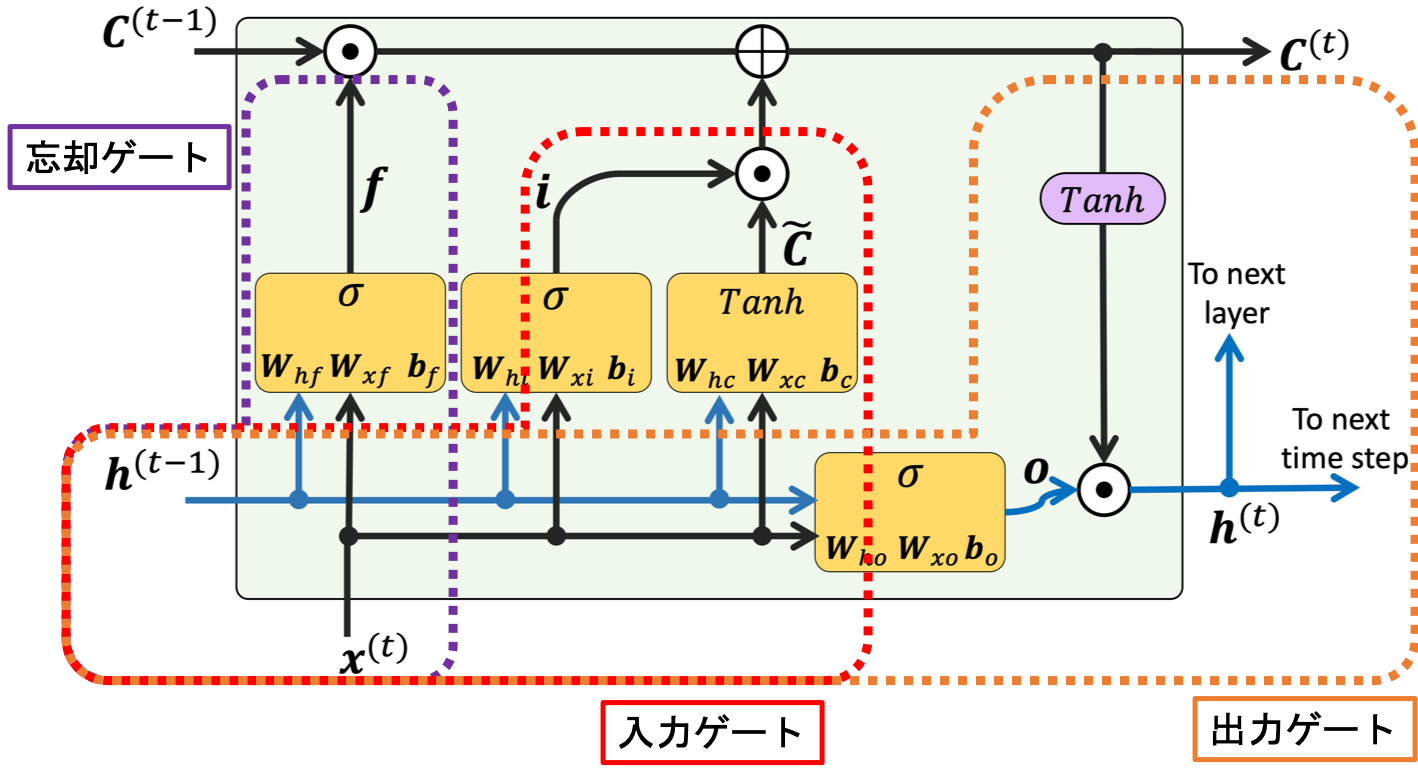
</div>

[画像引用元:Python Machine Learning](https://github.com/rasbt/python-machine-learning-book-2nd-edition)

### LSTMの順伝播

$\sigma$：シグモイド関数，　$\circ$：要素ごとの積  
$x^{(t)}$：時刻$t$の入力，$h^{(t-1)}$：時刻$t-1$の出力，$W_{vg}$：重み，$b_g$：バイアス，$C^{(t)}$：時刻$t$における記憶セル  
$A^{(t)}_g$:記憶率，$\tilde{C}$:候補値
$v$：入力$x$または前の出力$h$，$g$：各ゲート($f,i,o$)  

$$
\begin{eqnarray}
&&A^{(t)}_g&=&\sigma (W_{xg}x^{(t)} + W_{hg}h^{(t-1)} + b_g)\\
&&\tilde{C}&=&\tanh (W_{xc}x^{(t)} + W_{hc}h^{(t-1)} + b_c)\\
&&C^{(t)}&=&A^{(t)}_f \circ C^{(t-1)} + A^{(t)}_i \circ \tilde{C}\\
&&h^{(t)}&=&A^{(t)}_o \circ \tanh(C^{(t)})
\end{eqnarray}
$$

### LSTMの逆伝播

$\sigma$：シグモイド関数，　$\circ$：要素ごとの積  
$x^{(t)}$：時刻$t$の入力，$h^{(t-1)}$：時刻$t-1$の出力，$W_{vg}$：重み，$b_g$：バイアス，$C^{(t)}$：時刻$t$における記憶セル  
$A^{(t)}_g$:記憶率，$\tilde{C}$:候補値
$v$：入力$x$または前の出力$h$，$g$：各ゲート($f,i,o$)  

$$
\begin{eqnarray}
&&A^{(t)}_g&=&\sigma (\sum^{l}_{k=1} W_{hg}x^{(t)}_k,k + \sum^{m}_{k=1} W_{hg}y^{(t-1)}_k,k + b_g)\\
&&\tilde{C}&=&\tanh (W_{xc}x^{(t)} + W_{hc}h^{(t-1)} + b_c)\\
&&C^{(t)}&=&A^{(t)}_f \circ C^{(t-1)} + A^{(t)}_i \circ \tilde{C}\\
&&h^{(t)}&=&A^{(t)}_o \circ \tan(C^{(t)})
\end{eqnarray}
$$


In [2]:
## LSTM層
# a0:忘却ゲート　, a1:入力ゲート, a2:新しい記憶, a3:出力ゲート
# x:入力, y_prev:前の時刻の出力, c:記憶セル
# grad_y:出力の勾配, grad_c:記憶セルの勾配
# w, v:重み(4つの行列を含む配列)

class LSTMLayer:
    def __init__(self, n_upper, n):
        #W 各パラメータの初期値
        self.w = np.random.randn(4, n_upper, n) / np.sqrt(n_upper)  # Xavierの初期値
        self.v = np.random.randn(4, n, n) / np.sqrt(n)
        self.b = np.zeros((4, n))

    #W y_prev, c_prev: 前の時刻の出力と記憶セル
    def forward(self, x, y_prev, c_prev):
        u = np.matmul(x, self.w) + np.matmul(y_prev, self.v) + self.b.reshape(4, 1, -1)

        a0 = sigmoid(u[0])  # 忘却ゲート
        a1 = sigmoid(u[1])  # 入力ゲート
        a2 = np.tanh(u[2])  # 新しい記憶
        a3 = sigmoid(u[3])  # 出力ゲート
        self.gates = np.stack((a0, a1, a2, a3))

        self.c = a0*c_prev + a1*a2  # 記憶セル
        self.y = a3 * np.tanh(self.c)  # 出力
    
    def backward(self, x, y, c, y_prev, c_prev, gates, grad_y, grad_c):   
        a0, a1, a2, a3 = gates
        tanh_c = np.tanh(c)
        r = grad_c + (grad_y*a3) * (1-tanh_c**2)

        #W 各delta
        delta_a0 = r * c_prev * a0 * (1-a0)
        delta_a1 = r * a2 * a1 * (1-a1)
        delta_a2 = r * a1 * (1 - a2**2)
        delta_a3 = grad_y * tanh_c * a3 * (1 - a3)

        deltas = np.stack((delta_a0, delta_a1, delta_a2, delta_a3))

        #W 各パラメータの勾配
        self.grad_w += np.matmul(x.T, deltas)
        self.grad_v += np.matmul(y_prev.T, deltas)
        self.grad_b += np.sum(deltas, axis=1)

        #W xの勾配
        grad_x = np.matmul(deltas, self.w.transpose(0, 2, 1))
        self.grad_x = np.sum(grad_x, axis=0)

        #W y_prevの勾配
        grad_y_prev = np.matmul(deltas, self.v.transpose(0, 2, 1))
        self.grad_y_prev = np.sum(grad_y_prev, axis=0)
        
        #W c_prevの勾配
        self.grad_c_prev = r * a0

    #W 勾配を格納する行列の初期化（順伝播から逆伝播の間で使用）
    def reset_sum_grad(self):
        self.grad_w = np.zeros_like(self.w)
        self.grad_v = np.zeros_like(self.v)
        self.grad_b = np.zeros_like(self.b)

    #W 重み・バイアスの更新
    def update(self, eta):
        self.w -= eta * self.grad_w
        self.v -= eta * self.grad_v
        self.b -= eta * self.grad_b

## 3. 出力層

LSTM層で算出した結果を出力層に通すことで，適切な出力範囲に調整する．

In [3]:
## 全結合　出力層
class OutputLayer:
    def __init__(self, n_upper, n):
        #W Xavierの初期値
        self.w = np.random.randn(n_upper, n) / np.sqrt(n_upper)
        self.b = np.zeros(n)

    def forward(self, x):
        self.x = x
        u = np.dot(x, self.w) + self.b
        self.y = u  # 恒等関数

    def backward(self, t):
        delta = self.y - t
        
        self.grad_w = np.dot(self.x.T, delta)
        self.grad_b = np.sum(delta, axis=0)
        self.grad_x = np.dot(delta, self.w.T) 

    def update(self, eta):
        self.w -= eta * self.grad_w
        self.b -= eta * self.grad_b

## 4. 学習

**2.LSTM層**と**3.出力層**をモデルとして，学習を行う関数を作成します．  
フローチャートは以下のようになります．  
<div>
    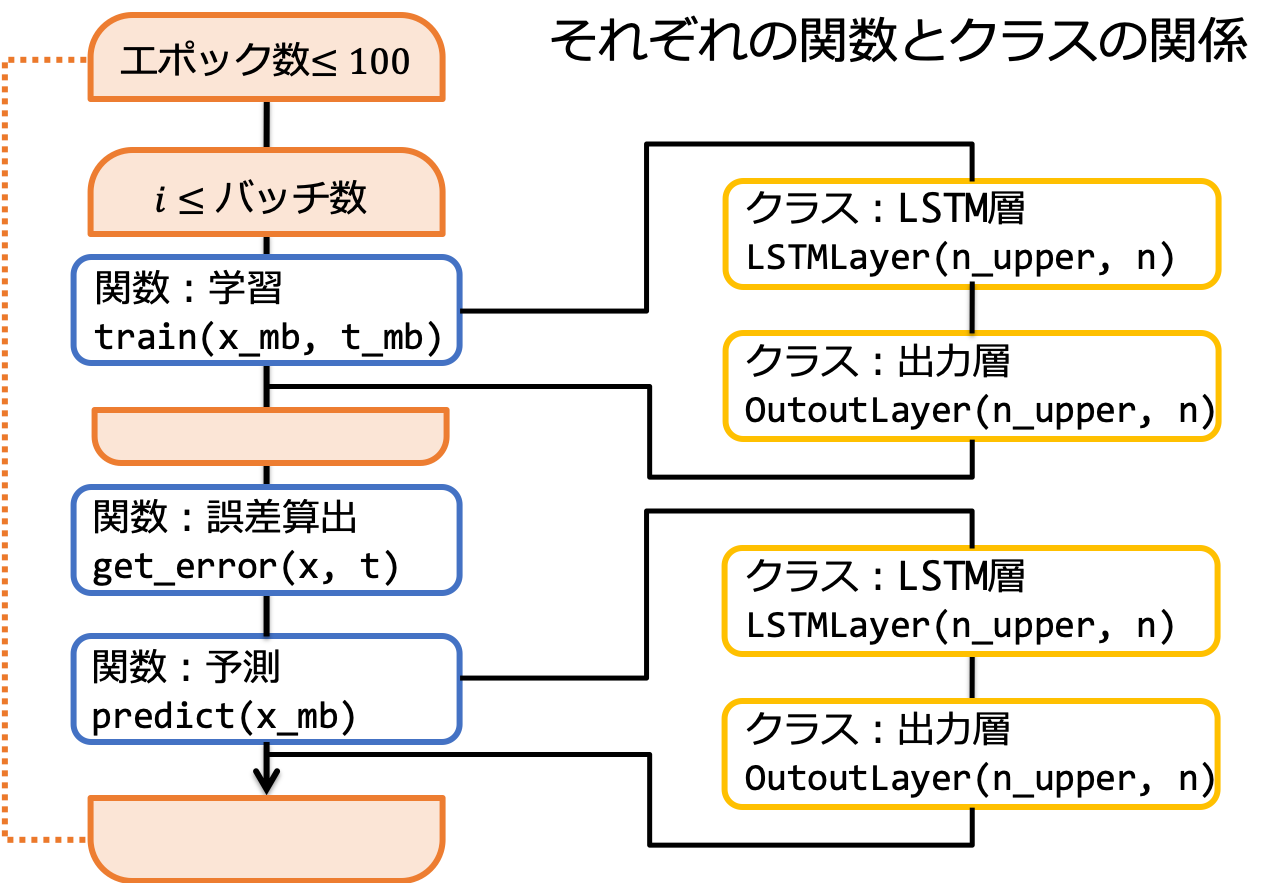
</div>

In [4]:
## 各層の初期化
lstm_layer = LSTMLayer(n_in, n_mid)
output_layer = OutputLayer(n_mid, n_out)

In [5]:
## 学習
def train(x_mb, t_mb):
    #W 順伝播 LSTM層
    y_rnn = np.zeros((len(x_mb), n_time+1, n_mid))
    c_rnn = np.zeros((len(x_mb), n_time+1, n_mid))
    gates_rnn = np.zeros((4, len(x_mb), n_time, n_mid))
    y_prev = y_rnn[:, 0, :]
    c_prev = c_rnn[:, 0, :]
    for i in range(n_time):
        x = x_mb[:, i, :]
        lstm_layer.forward(x, y_prev, c_prev)

        y = lstm_layer.y
        y_rnn[:, i+1, :] = y
        y_prev = y

        c = lstm_layer.c
        c_rnn[:, i+1, :] = c
        c_prev = c

        gates = lstm_layer.gates
        gates_rnn[:, :, i, :] = gates

    #W 順伝播 出力層
    output_layer.forward(y)

    #W 逆伝播 出力層
    output_layer.backward(t_mb)
    grad_y = output_layer.grad_x
    grad_c = np.zeros_like(lstm_layer.c)

    #W 逆伝播 LSTM層
    lstm_layer.reset_sum_grad()
    for i in reversed(range(n_time)):
        x = x_mb[:, i, :]
        y = y_rnn[:, i+1, :]
        c = c_rnn[:, i+1, :]
        y_prev = y_rnn[:, i, :]
        c_prev = c_rnn[:, i, :]
        gates = gates_rnn[:, :, i, :] 

        lstm_layer.backward(x, y, c, y_prev, c_prev, gates, grad_y, grad_c)
        grad_y = lstm_layer.grad_y_prev
        grad_c = lstm_layer.grad_c_prev

    #W パラメータの更新
    lstm_layer.update(eta)
    output_layer.update(eta)

## 5. 予測
**4.学習**で得られた結果から予測を行う関数を作成します．

In [6]:
## 予測
def predict(x_mb):
    # 順伝播 LSTM層
    y_prev = np.zeros((len(x_mb), n_mid))
    c_prev = np.zeros((len(x_mb), n_mid))
    for i in range(n_time):
        x = x_mb[:, i, :]
        lstm_layer.forward(x, y_prev, c_prev)
        y = lstm_layer.y
        y_prev = y
        c = lstm_layer.c
        c_prev = c

    # 順伝播 出力層
    output_layer.forward(y)
    return output_layer.y

## 6. 結果の可視化
エポック数ごとに**4.学習**と**5.予測**の関数を呼び出し，予測結果をグラフとして可視化します．
### 6.1 誤差を算出する関数を作成
教師データと学習結果の二乗和誤差を算出します．この関数は**6.2 結果をグラフとして出力**で呼び出されます．

In [7]:
## 誤差を計算(出力結果→Notebook末の学習誤差とEpoch数の関係図)
def get_error(x, t):
    y = predict(x)
    ## 二乗和誤差
    return 1.0/2.0*np.sum(np.square(y - t))

### 6.2 結果をグラフとして出力

学習結果を10エポックごとに増やしながら結果を比較していきます．  
60エポックを超えた辺りから与えたデータの最後までsin波の周期性が再現できるようになります．  
また，100エポックを超えてもノイズまでは詳細に表現することが困難であることがわかります．

最後にエポック数と誤差のグラフが出力されます．  
ある程度エポック数が増えると誤差の変化が非常に小さくなり，学習が止まりつつあると推測できます．

Epoch:1/101 Error:5.84417275711618


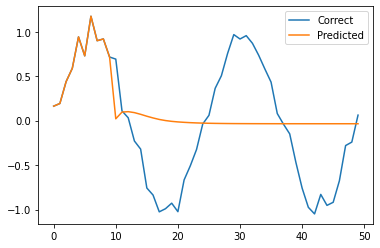

Epoch:11/101 Error:2.2941166852505894


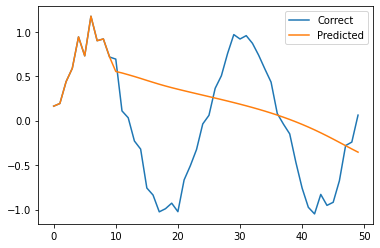

Epoch:21/101 Error:1.617190822646354


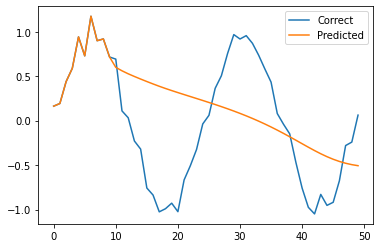

Epoch:31/101 Error:1.1027908129267299


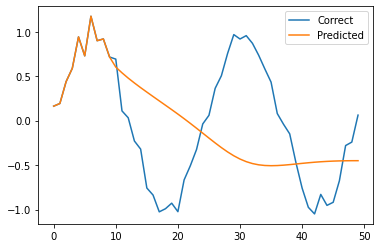

Epoch:41/101 Error:0.7222917133752669


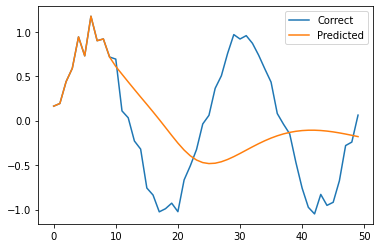

Epoch:51/101 Error:0.4903296165119149


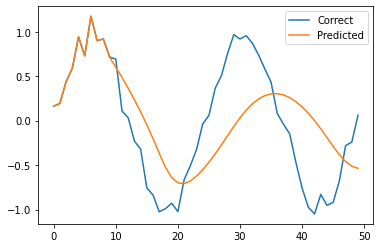

Epoch:61/101 Error:0.3798647061398135


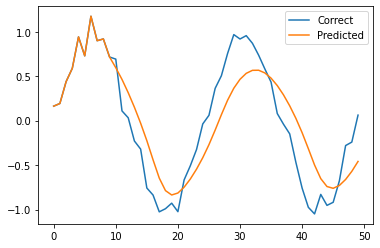

Epoch:71/101 Error:0.33375409911252496


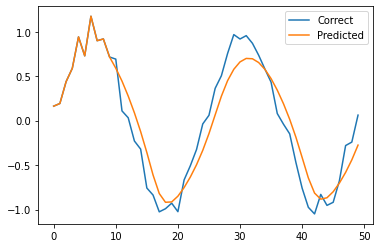

Epoch:81/101 Error:0.3139629389326768


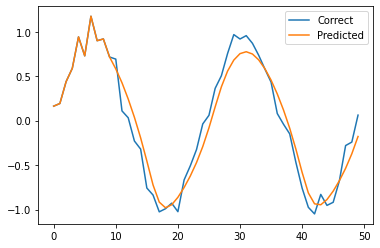

Epoch:91/101 Error:0.30372975308893446


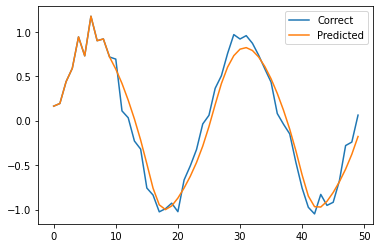

Epoch:101/101 Error:0.2968214984150979


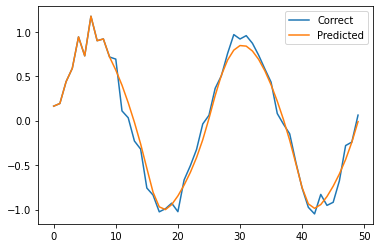

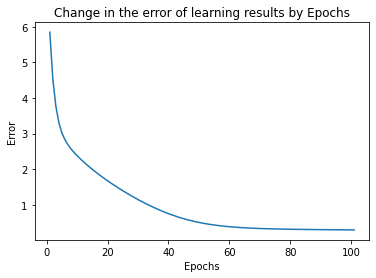

In [8]:
## 学習と結果のグラフ出力
error_record = []
n_batch = len(input_data) // batch_size  # 1エポックあたりのバッチ数
for i in range(epochs):
        
    ## 学習 ##
    index_random = np.arange(len(input_data))
    # インデックスをシャッフルする
    np.random.shuffle(index_random)
    for j in range(n_batch):
        
        # ミニバッチを取り出す
        mb_index = index_random[j*batch_size : (j+1)*batch_size]
        x_mb = input_data[mb_index, :]
        t_mb = correct_data[mb_index, :]
        train(x_mb, t_mb)

    ## 誤差を求める ##
    error = get_error(input_data, correct_data)
    error_record.append(error)

    ## 経過の表示 ## 
    if i%interval == 0:
        print("Epoch:"+str(i+1)+"/"+str(epochs), "Error:"+str(error))
        
        # 最初の入力
        predicted = input_data[0].reshape(-1).tolist()
        for i in range(n_sample):
            x = np.array(predicted[-n_time:]).reshape(1, n_time, 1)
            y = predict(x)
            # 出力をpredictedに追加する
            predicted.append(float(y[0, 0]))

        plt.plot(range(len(sin_y)), sin_y.tolist(), label="Correct")
        plt.plot(range(len(predicted)), predicted, label="Predicted")
        plt.legend()
        plt.show()

plt.plot(range(1, len(error_record)+1), error_record)
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Change in the error of learning results by Epochs")
plt.show()